# ============================================================
# PERSON 3 — Deep Learning (LSTM) + Flask API + Web UI
# NLP Customer Complaint Router — SAP ABAP Capstone Project
# ============================================================
# FILE 1: dl_model.py  — Train LSTM model
# FILE 2: app.py       — Flask API + Web UI  (separate section below)
# ============================================================

# ╔══════════════════════════════════════════════════════════╗
# ║  FILE 1: dl_model.py — LSTM Deep Learning Model         ║
# ╚══════════════════════════════════════════════════════════╝

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Input

In [12]:
# ── STEP 1: Load Data ──────────────────────────────────────────────────────────

print("📦 Loading data...")
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

X_train = train_df['cleaned_complaint'].astype(str)
X_test  = test_df['cleaned_complaint'].astype(str)

le = LabelEncoder()
y_train = le.fit_transform(train_df['category'])
y_test  = le.transform(test_df['category'])
num_classes = len(le.classes_)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f"✅ Classes: {list(le.classes_)}")


📦 Loading data...
✅ Classes: ['Account Issue', 'Billing Issue', 'Delivery Problem', 'Product Defect', 'Refund Request']


In [13]:
# ── STEP 2: Tokenize & Pad ─────────────────────────────────────────────────────

MAX_WORDS  = 10000
MAX_LEN    = 50
EMBED_DIM  = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

print(f"✅ Sequence shape: {X_train_seq.shape}")


✅ Sequence shape: (800, 50)


In [15]:
# ── STEP 3: Build Bidirectional LSTM ──────────────────────────────────────────

model = Sequential([
    Input(shape=(MAX_LEN,)),
    
    Embedding(MAX_WORDS, EMBED_DIM),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 50, 64)              │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 50, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 751,749 (2.87 MB)

 Trainable params: 751,749 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ── STEP 4: Train ─────────────────────────────────────────────────────────────

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\n🔄 Training LSTM model...")
history = model.fit(
    X_train_seq, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)


🔄 Training LSTM model...
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 362ms/step - accuracy: 0.2118 - loss: 1.6106 - val_accuracy: 0.1750 - val_loss: 1.6017 - learning_rate: 0.0010
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.2853 - loss: 1.5884 - val_accuracy: 0.6333 - val_loss: 1.5227 - learning_rate: 0.0010
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5147 - loss: 1.2442 - val_accuracy: 0.6500 - val_loss: 0.7546 - learning_rate: 0.0010
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.6088 - loss: 0.7308 - val_accuracy: 0.8000 - val_loss: 0.5659 - learning_rate: 0.0010
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.5971 - loss: 0.6977 - val_accuracy: 0.8667 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.6588 - loss: 0.5848 - val_accuracy: 0.8000 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accurac

In [18]:
# ── STEP 5: Evaluate ──────────────────────────────────────────────────────────

loss, acc = model.evaluate(X_test_seq, y_test_cat, verbose=0)
preds     = np.argmax(model.predict(X_test_seq), axis=1)
f1        = f1_score(y_test, preds, average='weighted')

print(f"\n✅ LSTM Results:")
print(f"   Test Accuracy: {acc:.4f}")
print(f"   Test F1 Score: {f1:.4f}")
print(f"\n{classification_report(y_test, preds, target_names=le.classes_)}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

✅ LSTM Results:
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000

                  precision    recall  f1-score   support

   Account Issue       1.00      1.00      1.00        42
   Billing Issue       1.00      1.00      1.00        38
Delivery Problem       1.00      1.00      1.00        41
  Product Defect       1.00      1.00      1.00        39
  Refund Request       1.00      1.00      1.00        40

        accuracy                           1.00       200
       macro avg       1.00      1.00      1.00       200
    weighted avg       1.00      1.00      1.00       200



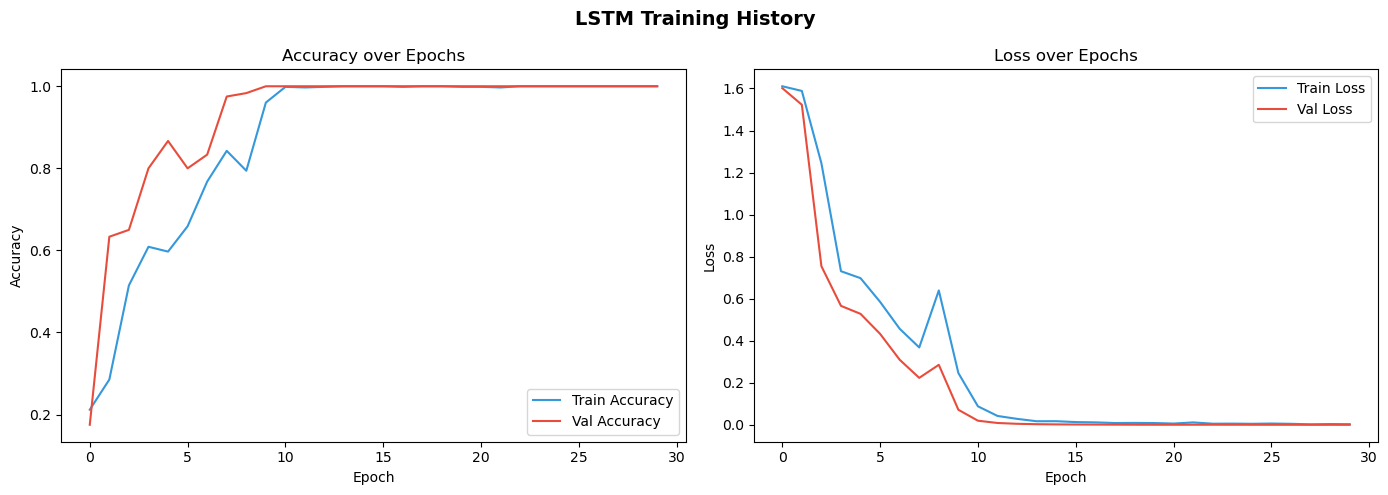

✅ Training history saved as lstm_training.png


In [19]:
# ── STEP 6: Plot Training History ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='#3498DB')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#E74C3C')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train Loss', color='#3498DB')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='#E74C3C')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved as lstm_training.png")


In [24]:
# ── STEP 7: Save DL Model ─────────────────────────────────────────────────────

model.save('model_lstm.keras')
model.save('model_lstm.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
joblib.dump(le, 'label_encoder_dl.pkl')

print("\n✅ DL model saved:")
print("   model_lstm.h5")
print("   tokenizer.pkl")
print("   label_encoder_dl.pkl")
print("\n🎯 DL training complete! Now run app.py to start the Flask API.")


✅ DL model saved:
   model_lstm.h5
   tokenizer.pkl
   label_encoder_dl.pkl

🎯 DL training complete! Now run app.py to start the Flask API.
